## Insight Visualizations

#### Importing Necessary Packages

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

#### Set output path

In [37]:
sns.set_style('whitegrid')
plt.rcParams['font.size'] = 12
OUTPUT_PATH = '../visualizations/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

#### Load data from analyze_insights.py

In [38]:
sentiment_df = pd.read_csv('../data/processed/sentiment_distribution.csv', index_col='bank_name')
theme_df = pd.read_csv('../data/processed/theme_distribution.csv', index_col='bank_name')
rating_df = pd.read_csv('../data/processed/sentiment_vs_rating.csv')

#### Basic Dataset Lookup

In [39]:
sentiment_df

,NEGATIVE,POSITIVE
bank_name,,
Bank of Abyssinia,225.0,104.0
Commercial Bank of Ethiopia,79.0,218.0
Dashen Bank,53.0,295.0


In [40]:
theme_df

,Account Access,Customer Support,Feature Requests,Other,Reliability,Transaction Performance,User Interface
bank_name,,,,,,,
Bank of Abyssinia,9.0,25.0,43.0,216.0,31.0,38.0,7.0
Commercial Bank of Ethiopia,0.0,13.0,24.0,217.0,9.0,24.0,22.0
Dashen Bank,5.0,29.0,69.0,203.0,5.0,61.0,64.0


In [41]:
rating_df

,Unnamed: 0,bank_name,sentiment_label,rating,count
0,0,Bank of Abyssinia,NEGATIVE,3,19
1,1,Bank of Abyssinia,NEGATIVE,1,192
2,2,Bank of Abyssinia,POSITIVE,5,88
3,3,Bank of Abyssinia,POSITIVE,3,7
4,4,Bank of Abyssinia,POSITIVE,4,9
5,5,Bank of Abyssinia,NEGATIVE,2,14
6,6,Commercial Bank of Ethiopia,POSITIVE,4,38
7,7,Commercial Bank of Ethiopia,POSITIVE,5,177
8,8,Commercial Bank of Ethiopia,NEGATIVE,2,14
9,9,Commercial Bank of Ethiopia,NEGATIVE,1,45


#### Sentiment Distribution by Bank

<Figure size 1000x600 with 0 Axes>

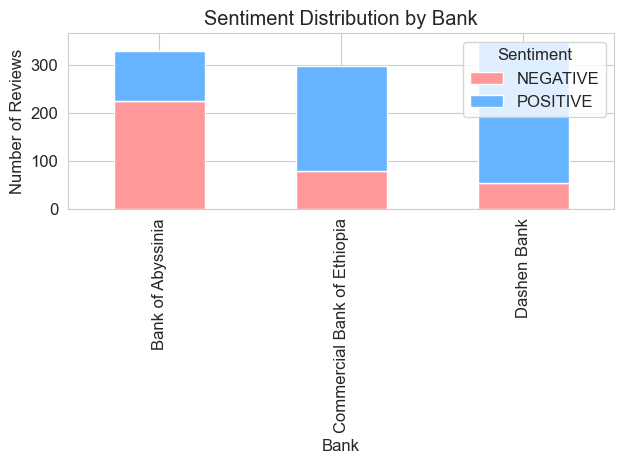

In [42]:
plt.figure(figsize=(10, 6))
sentiment_df.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'])
plt.title('Sentiment Distribution by Bank')
plt.xlabel('Bank')
plt.ylabel('Number of Reviews')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'sentiment_distribution_task4.png'))
plt.show()
plt.close()

#### Plot Heatmap for Theme Distribution

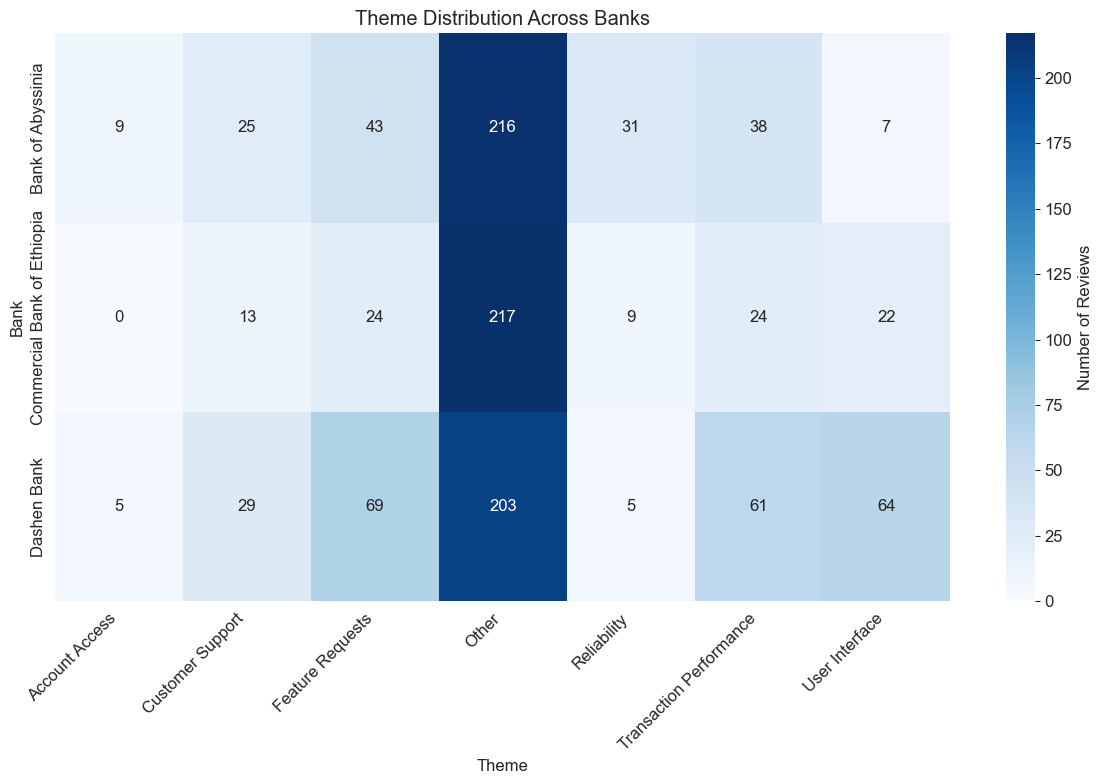

In [43]:
plt.figure(figsize=(12, 8))
sns.heatmap(theme_df, annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': 'Number of Reviews'})
plt.title('Theme Distribution Across Banks')
plt.xlabel('Theme')
plt.ylabel('Bank')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'theme_distribution_task4.png'), dpi=300)
plt.show()
plt.close()

#### Theme Distribution by Bank

<Figure size 1200x800 with 0 Axes>

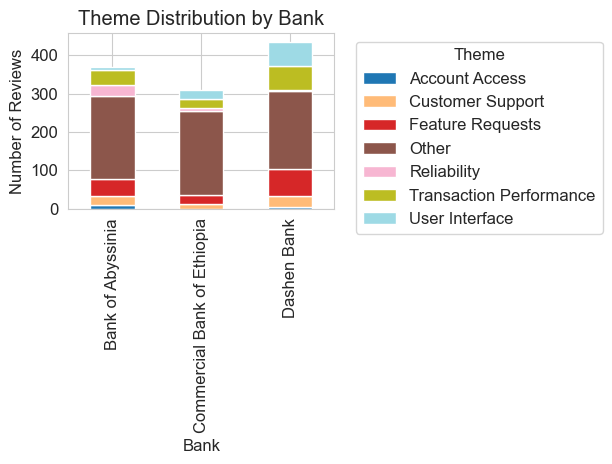

In [44]:
plt.figure(figsize=(12, 8))
theme_df.plot(kind='bar', stacked=True, cmap='tab20')
plt.title('Theme Distribution by Bank')
plt.xlabel('Bank')
plt.ylabel('Number of Reviews')
plt.legend(title='Theme', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'theme_distribution_task4.png'))
plt.show()
plt.close()

#### Plot 3: Sentiment vs. Rating by Bank

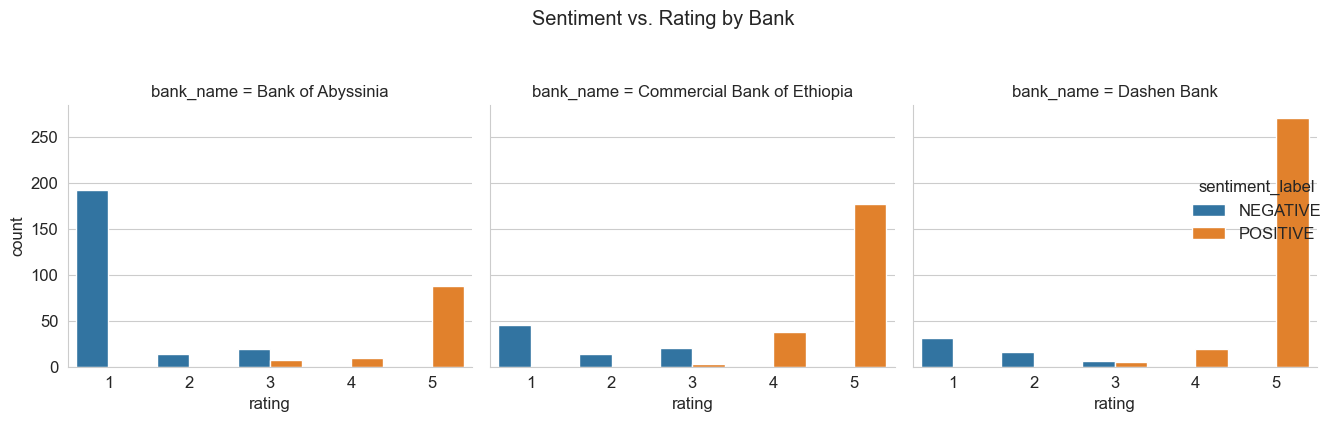

In [45]:
g = sns.catplot(data=rating_df, x='rating', y='count', hue='sentiment_label', col='bank_name', kind='bar', height=4, aspect=1)
g.fig.suptitle('Sentiment vs. Rating by Bank', y=1.05)
plt.tight_layout()
g.savefig(os.path.join(OUTPUT_PATH, 'sentiment_vs_rating_task4.png'))
plt.show()
plt.close()

#### Plot Pie Chart for BOA Theme Proportions

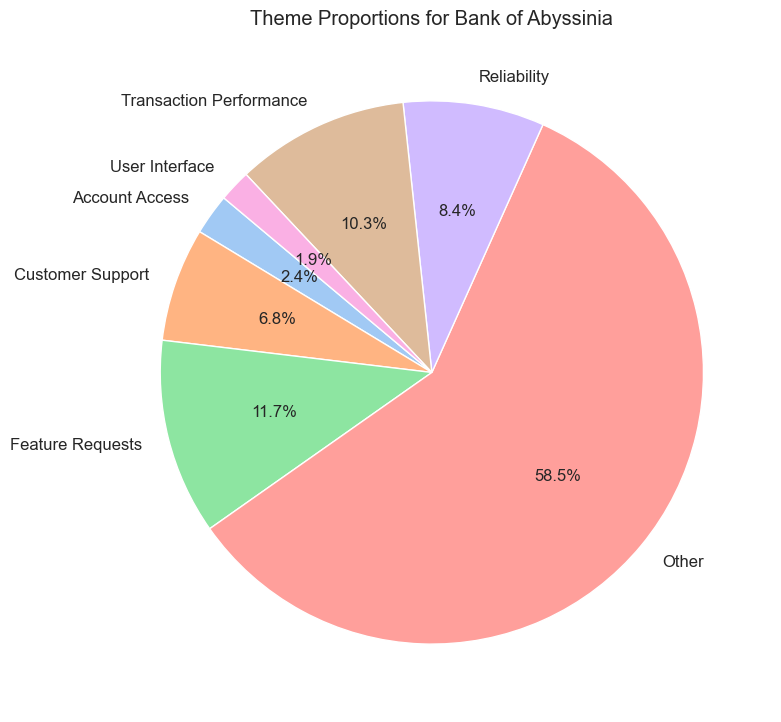

In [46]:
boa_themes = theme_df.loc['Bank of Abyssinia'].reset_index().rename(columns={'index': 'Theme', 'Bank of Abyssinia': 'Count'})
plt.figure(figsize=(8, 8))
plt.pie(boa_themes['Count'], labels=boa_themes['Theme'], autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=140)
plt.title('Theme Proportions for Bank of Abyssinia')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'boa_theme_proportions_task4.png'), dpi=300)
plt.show()
plt.close()